# Oltalama (Phishing) Web Sitelerinin Tespiti

## BLM463 - Veri Madenciligi Donem Projesi

 Koray Garip - 22360859088  

---

### Projenin Amaci

Bu projede, kullanicilari dolandirmayi hedefleyen **sahte (Phishing)** web siteleri ile **gercek (Legitimate)** web sitelerini makine ogrenmesi algoritmalari kullanarak otomatik ve yuksek dogrulukla ayirt edebilen modeller gelistirilmistir.

### Kullanilan Veri Seti

**PhiUSIIL Phishing URL Dataset** - UCI Machine Learning Repository  
~235.000 URL kaydi, 54+ ozellik sutunu

### Sunum Akisi

| Bolum | Konu |
|---|---|
| 1 | Veri Kesfi ve On Inceleme |
| 2 | Veri On Isleme ve Ozellik Muhendisligi |
| 3 | Random Forest - Temel Model |
| 4 | Ozellik Seciminin Etkisi |
| 5 | Diger ML Modellerinin Karsilastirmasi |
| 6 | Dayaniklilik Testleri |
| 7 | Sonuc ve Degerlendirme |

---

## BOLUM 1: VERI KESFI VE ON INCELEME

Bu bolumde veri setimizi yukleyecek, yapisini inceleyecek ve sinif dagilimini gorsellestiriyoruz.

In [1]:
# gerekli kutuphanelerin import edilmesi
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

# sabitler
PHISHING_LABEL = 0
LEGITIMATE_LABEL = 1
RANDOM_STATE = 42

print('kutuphaneler basariyla yuklendi')

kutuphaneler basariyla yuklendi


In [5]:
# veri setinin yuklenmesi
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

# sinif dagilimi
label_counts = df['label'].value_counts()
legitimate_count = int(label_counts.get(1, 0))
phishing_count = int(label_counts.get(0, 0))

total_count = len(df)
total_features = df.shape[1]
missing_count = int(df.isnull().sum().sum())

legitimate_ratio = legitimate_count / total_count * 100
phishing_ratio = phishing_count / total_count * 100

# ozet tablo
summary_df = pd.DataFrame({
    'Ozellik': [
        'Toplam örnek sayısı',
        'Toplam sütun sayısı',
        'Eksik değer sayısı',
        'Legitimate URL sayısı',
        'Phishing URL sayısı',
        'Legitimate oranı',
        'Phishing oranı'
    ],
    'Değer': [
        f'{total_count:,}'.replace(',', '.'),
        f'{total_features}',
        f'{missing_count}',
        f'{legitimate_count:,}'.replace(',', '.'),
        f'{phishing_count:,}'.replace(',', '.'),
        f'%{legitimate_ratio:.4f}'.replace('.', ','),
        f'%{phishing_ratio:.4f}'.replace('.', ',')
    ]
})

print(summary_df.to_string())

                 Ozellik     Değer
0    Toplam örnek sayısı   235.795
1    Toplam sütun sayısı        56
2     Eksik değer sayısı         0
3  Legitimate URL sayısı   134.850
4    Phishing URL sayısı   100.945
5       Legitimate oranı  %57,1895
6         Phishing oranı  %42,8105


In [6]:
# veri seti genel bilgileri
print('veri seti genel bilgileri')
print(f'\nboyut: {df.shape[0]:,} satir x {df.shape[1]} sutun')
print(f'eksik deger sayisi: {df.isnull().sum().sum()}')
print(f'\nveri tipleri:')
print(df.dtypes.value_counts())
print(f'\nmetinsel sutunlar: {df.select_dtypes(include=["object"]).columns.tolist()}')
print(f'\nsayisal sutunlar ({len(df.select_dtypes(include=[np.number]).columns)} adet):')
print(df.select_dtypes(include=[np.number]).columns.tolist())

veri seti genel bilgileri

boyut: 235,795 satir x 56 sutun
eksik deger sayisi: 0

veri tipleri:
int64      41
float64    10
str         5
Name: count, dtype: int64

metinsel sutunlar: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

sayisal sutunlar (51 adet):
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank

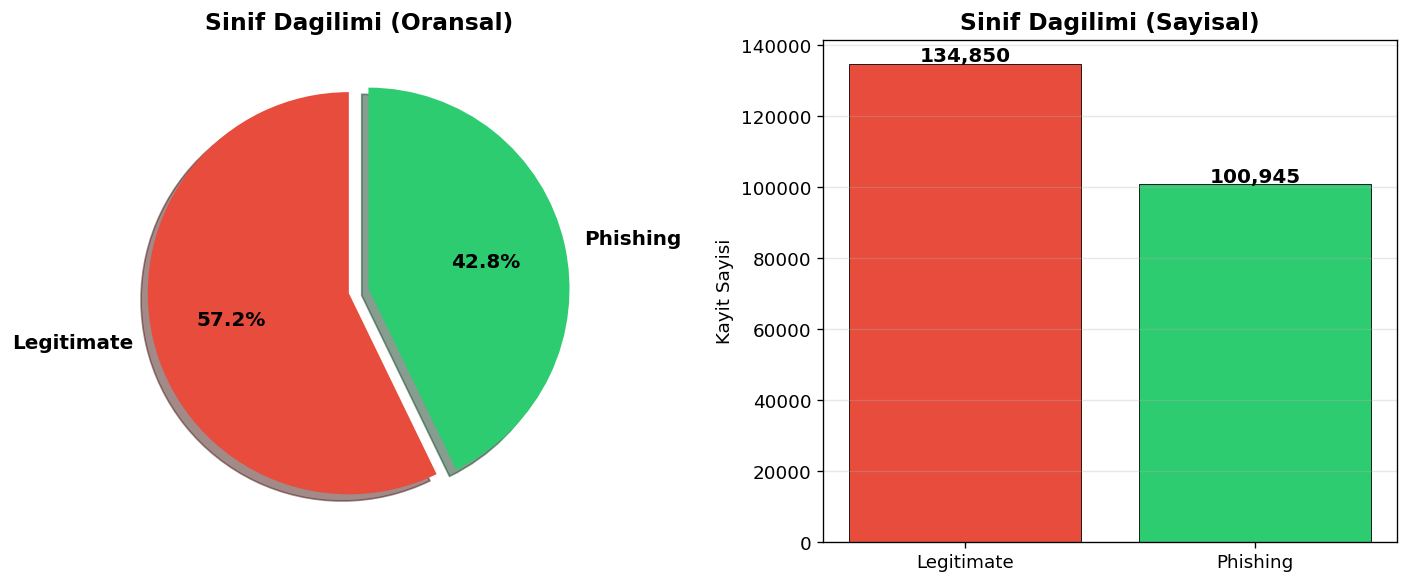


phishing: 100,945 kayit
legitimate: 134,850 kayit


In [7]:
# sinif dagilimi gorsellestirme
label_counts = df['label'].value_counts()
label_names = {0: 'Phishing', 1: 'Legitimate'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pasta grafik
colors = ['#e74c3c', '#2ecc71']
axes[0].pie(
    label_counts.values,
    labels=[label_names[i] for i in label_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Sinif Dagilimi (Oransal)', fontsize=14, fontweight='bold')

# bar grafik
bars = axes[1].bar(
    [label_names[i] for i in label_counts.index],
    label_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Sinif Dagilimi (Sayisal)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Kayit Sayisi')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nphishing: {label_counts.get(0, 0):,} kayit')
print(f'legitimate: {label_counts.get(1, 0):,} kayit')

In [8]:
# ilk 5 satir - veri setine goz atalim
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


---

## BOLUM 2: VERI ON ISLEME VE OZELLIK MUHENDISLIGI

Bu bolumde:
1. **Metin sutunlarini** (URL, Domain, vb.) cikaracagiz - model sayisal verilerle calisir
2. **Supheli/sizan ozellikleri** (hedef bilgisini dolayli tasiyan sutunlar) belirleyecegiz
3. **2 farkli ozellik seti** olusturacagiz (Feature Ablation Study)

In [9]:
# hedef degisken ve cikarilacak sutunlar
target_column = 'label'

# metin sutunlari - model tarafindan kullanilamaz
text_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f'cikarilacak metin sutunlari ({len(text_columns)}): {text_columns}')

# hedef bilgisi sizdirma riski tasiyan sutunlar
suspicious_columns = [
    'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
    'URLCharProb', 'DomainTitleMatchScore', 'URLTitleMatchScore'
]
suspicious_columns = [col for col in suspicious_columns if col in df.columns]
print(f'\nsupheli (potansiyel sizinti) sutunlar ({len(suspicious_columns)}): {suspicious_columns}')

cikarilacak metin sutunlari (5): ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

supheli (potansiyel sizinti) sutunlar (6): ['URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'DomainTitleMatchScore', 'URLTitleMatchScore']


In [10]:
# 2 farkli ozellik seti olusturma
y = df[target_column]

# 1. tum sayisal ozellikler (metin cikarilmis)
X_all = df.drop(columns=text_columns + [target_column])

# 2. kontrollu ozellik seti (metin + supheli sutunlar cikarilmis)
X_controlled = df.drop(columns=text_columns + suspicious_columns + [target_column])

print('ozellik setleri hazir')
print(f'1. tum sayisal ozellikler:    {X_all.shape[1]} ozellik')
print(f'2. kontrollu ozellik seti:    {X_controlled.shape[1]} ozellik')
print(f'\ntoplam kayit: {len(y):,}')

ozellik setleri hazir
1. tum sayisal ozellikler:    50 ozellik
2. kontrollu ozellik seti:    44 ozellik

toplam kayit: 235,795


In [11]:
# train / validation / test bolunmesi (%70 / %15 / %15)
def train_val_test_split(X, y, random_state=RANDOM_STATE):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=random_state, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# kontrollu set uzerinden bolme 
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X_controlled, y)

print('veri bolunmesi (kontrollu ozellik seti)')
print(f'egitim (train):     {X_train.shape[0]:,} kayit ({X_train.shape[0]/len(y)*100:.0f}%)')
print(f'dogrulama (val):    {X_val.shape[0]:,} kayit ({X_val.shape[0]/len(y)*100:.0f}%)')
print(f'test:               {X_test.shape[0]:,} kayit ({X_test.shape[0]/len(y)*100:.0f}%)')

veri bolunmesi (kontrollu ozellik seti)
egitim (train):     165,056 kayit (70%)
dogrulama (val):    35,369 kayit (15%)
test:               35,370 kayit (15%)


---

## BOLUM 3: RANDOM FOREST - TEMEL MODEL

**Random Forest**, birden fazla karar agacini birlestirerek guclu bir topluluk (ensemble) modeli olusturur.

Bu bolumde **Kontrollu Ozellik Seti** ile temel modelimizi egitecegiz.

**Parametreler:**
- `n_estimators = 100` - 100 karar agaci
- `class_weight = 'balanced'` - sinif dengesizligini otomatik kompanze eder
- `n_jobs = -1` - tum CPU cekirdeklerini kullanir

In [12]:
# random forest modelini egitme (kontrollu ozellik seti)
print('random forest modeli egitiliyor...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# tahminler
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# metrikler
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f'\nmodel egitimi tamamlandi')
print(f'validation accuracy: %{val_acc*100:.4f}')
print(f'test accuracy:       %{test_acc*100:.4f}')

random forest modeli egitiliyor...

model egitimi tamamlandi
validation accuracy: %99.9859
test accuracy:       %99.9746


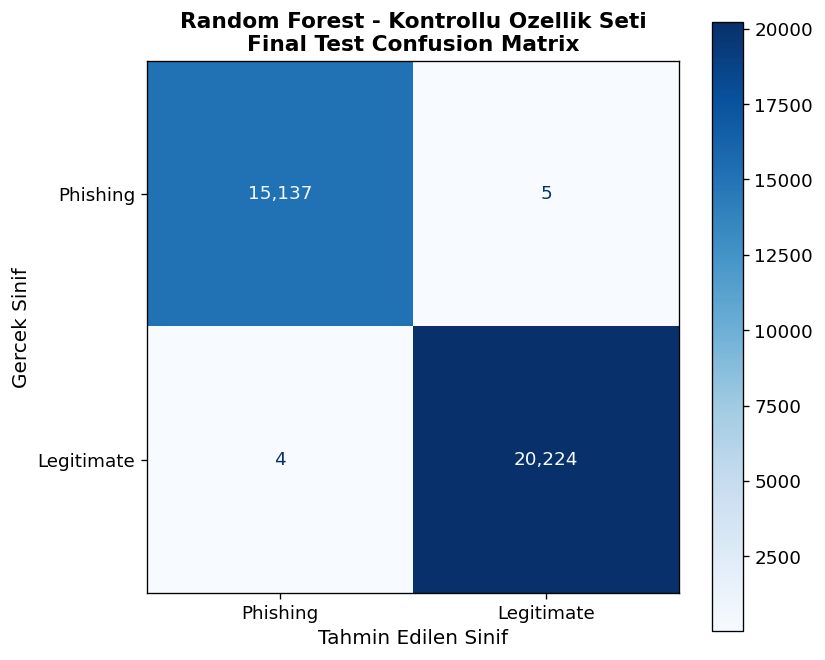

tp (phishing dogru tespit):        15,137
fn (phishing kacirilan):           5
fp (legitimate yanlis alarm):      4
tn (legitimate dogru tespit):      20,224


In [13]:
# confusion matrix gorsellestirme
cm = confusion_matrix(y_test, y_test_pred, labels=[PHISHING_LABEL, LEGITIMATE_LABEL])

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Phishing', 'Legitimate']
)
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Random Forest - Kontrollu Ozellik Seti\nFinal Test Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin Edilen Sinif', fontsize=12)
ax.set_ylabel('Gercek Sinif', fontsize=12)
plt.tight_layout()
plt.show()

tp, fn = cm[0, 0], cm[0, 1]
fp, tn = cm[1, 0], cm[1, 1]
print(f'tp (phishing dogru tespit):        {tp:,}')
print(f'fn (phishing kacirilan):           {fn:,}')
print(f'fp (legitimate yanlis alarm):      {fp:,}')
print(f'tn (legitimate dogru tespit):      {tn:,}')

In [14]:
# classification report
print('siniflandirma raporu (final test)')
print(classification_report(
    y_test, y_test_pred,
    labels=[PHISHING_LABEL, LEGITIMATE_LABEL],
    target_names=['Phishing', 'Legitimate'],
    digits=6
))

siniflandirma raporu (final test)
              precision    recall  f1-score   support

    Phishing   0.999736  0.999670  0.999703     15142
  Legitimate   0.999753  0.999802  0.999778     20228

    accuracy                       0.999746     35370
   macro avg   0.999744  0.999736  0.999740     35370
weighted avg   0.999746  0.999746  0.999746     35370



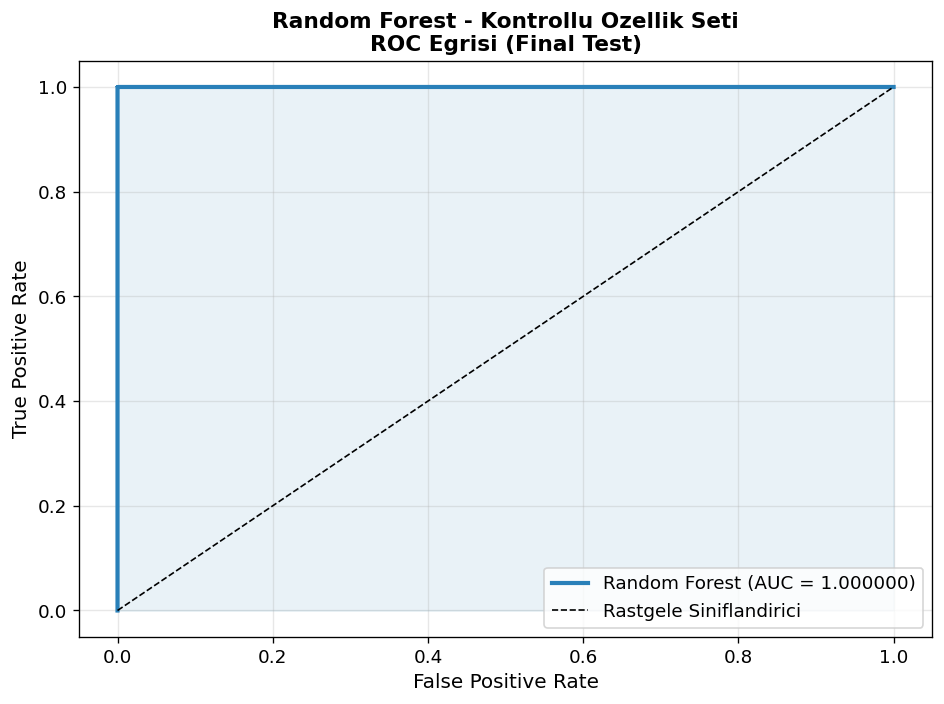

phishing roc-auc: 1.000000


In [15]:
# roc egrisi
y_test_proba = rf_model.predict_proba(X_test)
phishing_idx = list(rf_model.classes_).index(PHISHING_LABEL)
phishing_score = y_test_proba[:, phishing_idx]
y_true_binary = (y_test == PHISHING_LABEL).astype(int)

fpr, tpr, _ = roc_curve(y_true_binary, phishing_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2980b9', linewidth=2.5,
         label=f'Random Forest (AUC = {roc_auc:.6f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Siniflandirici')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest - Kontrollu Ozellik Seti\nROC Egrisi (Final Test)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'phishing roc-auc: {roc_auc:.6f}')

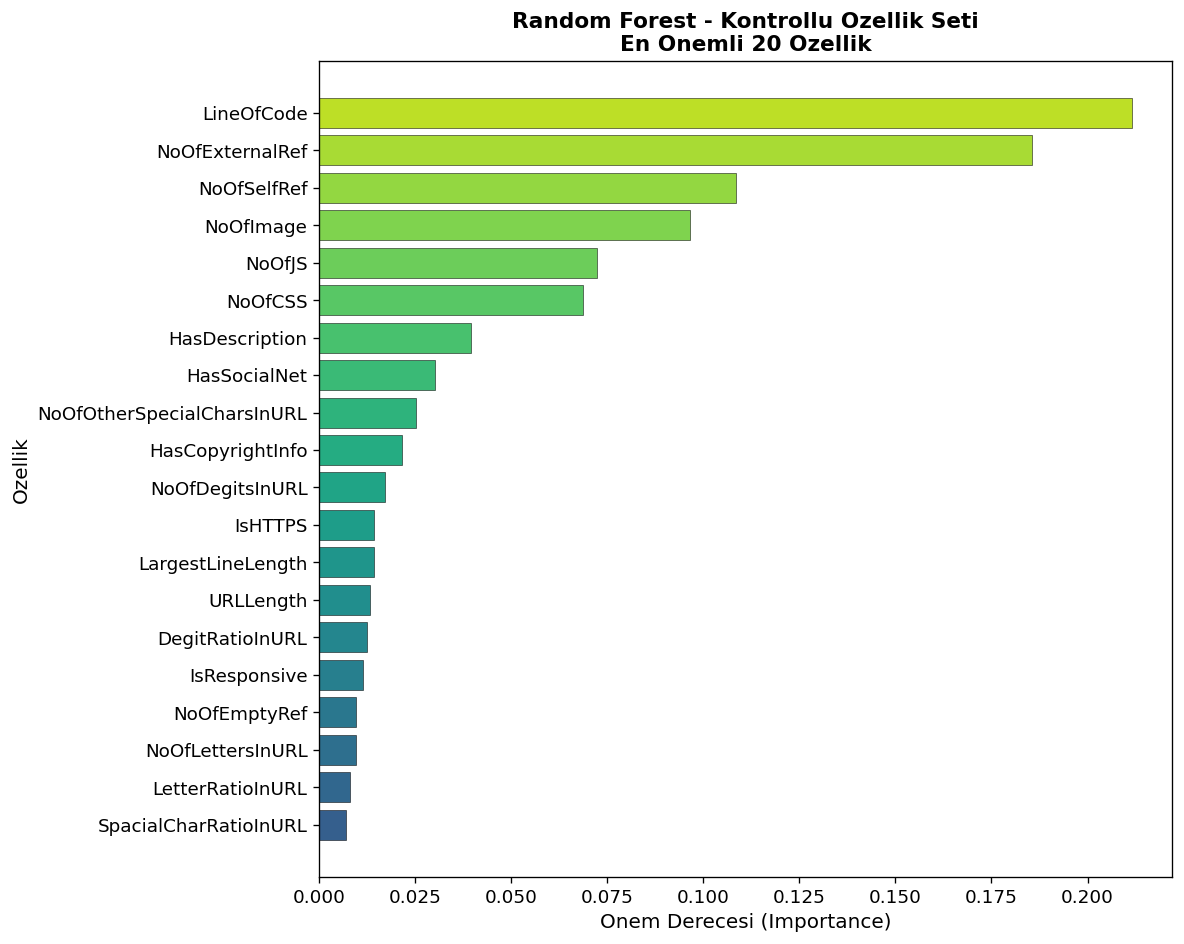


en onemli 5 ozellik:
        Feature  Importance
     LineOfCode    0.211523
NoOfExternalRef    0.185658
    NoOfSelfRef    0.108604
      NoOfImage    0.096508
         NoOfJS    0.072328


In [16]:
# feature importance - en onemli 20 ozellik
feature_importance = pd.DataFrame({
    'Feature': X_controlled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
plt.barh(top_features['Feature'], top_features['Importance'], color=colors, edgecolor='black', linewidth=0.3)
plt.xlabel('Onem Derecesi (Importance)', fontsize=12)
plt.ylabel('Ozellik', fontsize=12)
plt.title(f'Random Forest - Kontrollu Ozellik Seti\nEn Onemli {top_n} Ozellik',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nen onemli 5 ozellik:')
print(feature_importance.head(5).to_string(index=False))

---

## BOLUM 4: OZELLIK SECIMININ ETKISI 

Ayni Random Forest algoritmasini **2 farkli ozellik seti** ile egiterek, **hangi ozelliklerin model performansini nasil etkiledigini** inceliyoruz.


| # | Ozellik Seti | Aciklama |
|---|---|---|
| 1 | Tum Sayisal | Metin sutunlari cikarilmis, geri kalan tum sayisal ozellikler - hedef sizintisi olabilecek sutunlar dahil |
| 2 | Kontrollu | Metin + supheli sizinti riski tasiyan sutunlar cikarilmis - daha guvenilir ve gercekci sonuclar verir |

In [17]:
# 2 ozellik seti ile model egitimi ve karsilastirma
feature_sets = {
    'Tum Sayisal Ozellikler': X_all,
    'Kontrollu Ozellik Seti': X_controlled
}

rf_results = {}

for name, X_feat in feature_sets.items():
    print(f'\n{name} ({X_feat.shape[1]} ozellik)')
    
    Xtr, Xv, Xte, ytr, yv, yte = train_val_test_split(X_feat, y)
    
    model = RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        n_jobs=1, class_weight='balanced'
    )
    model.fit(Xtr, ytr)
    
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)
    
    ph_idx = list(model.classes_).index(PHISHING_LABEL)
    ph_score = y_proba[:, ph_idx]
    y_bin = (yte == PHISHING_LABEL).astype(int)
    f, t, _ = roc_curve(y_bin, ph_score)
    r_auc = auc(f, t)
    
    acc = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    rec = recall_score(yte, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    f1 = f1_score(yte, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    
    rf_results[name] = {
        'model': model,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': r_auc,
        'FPR': f, 'TPR': t, 'n_features': X_feat.shape[1]
    }
    
    print(f'  accuracy:  %{acc*100:.4f}')
    print(f'  f1-score:  %{f1*100:.4f}')
    print(f'  roc-auc:   {r_auc:.6f}')

print('\n2 ozellik seti ile egitim tamamlandi')


Tum Sayisal Ozellikler (50 ozellik)
  accuracy:  %99.9972
  f1-score:  %99.9967
  roc-auc:   1.000000

Kontrollu Ozellik Seti (44 ozellik)
  accuracy:  %99.9746
  f1-score:  %99.9703
  roc-auc:   1.000000

2 ozellik seti ile egitim tamamlandi


In [18]:
# karsilastirma tablosu
comparison_rows = []
for name, res in rf_results.items():
    comparison_rows.append({
        'Ozellik Seti': name,
        'Ozellik Sayisi': res['n_features'],
        'Accuracy (%)': round(res['Accuracy'] * 100, 4),
        'Precision (%)': round(res['Precision'] * 100, 4),
        'Recall (%)': round(res['Recall'] * 100, 4),
        'F1-Score (%)': round(res['F1-Score'] * 100, 4),
        'ROC-AUC': round(res['ROC-AUC'], 6)
    })

df_rf_comparison = pd.DataFrame(comparison_rows)
print('ozellik seti karsilastirma tablosu')
print(df_rf_comparison.to_string(index=False))

ozellik seti karsilastirma tablosu
          Ozellik Seti  Ozellik Sayisi  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC
Tum Sayisal Ozellikler              50       99.9972       100.0000     99.9934       99.9967      1.0
Kontrollu Ozellik Seti              44       99.9746        99.9736     99.9670       99.9703      1.0


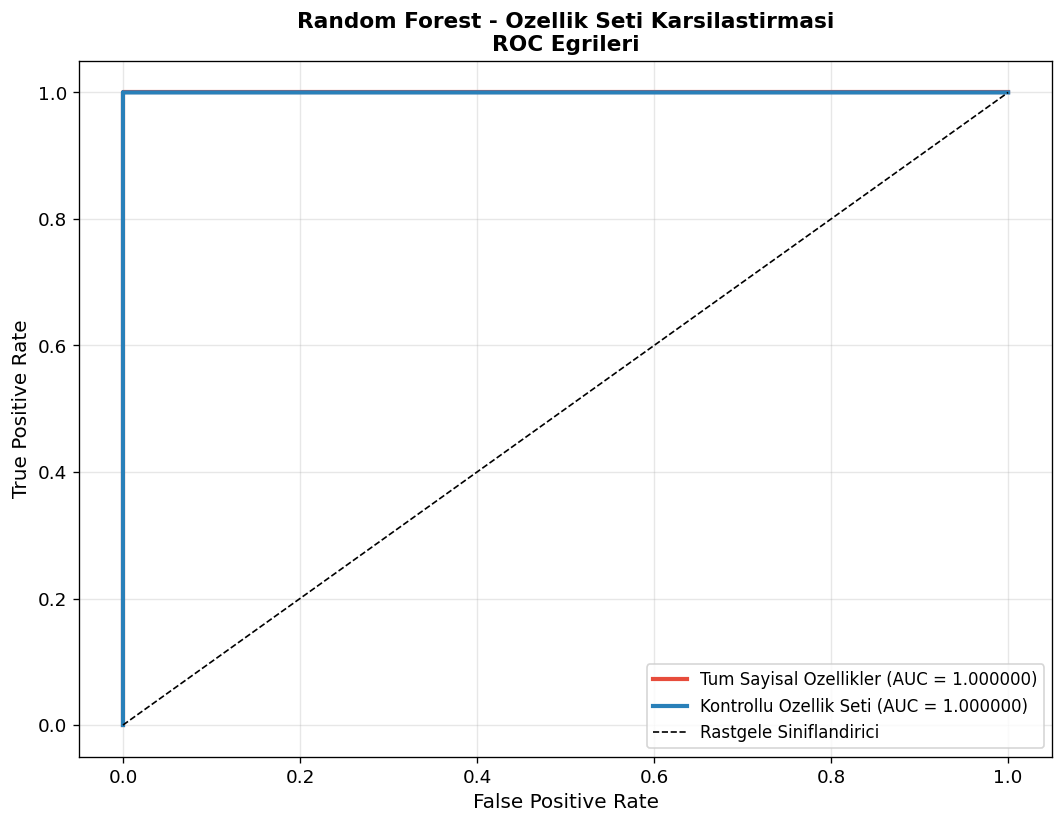

In [19]:
# 2 rf modelinin roc egrileri (ust uste)
plt.figure(figsize=(9, 7))

colors_roc = ['#e74c3c', '#2980b9']
for i, (name, res) in enumerate(rf_results.items()):
    plt.plot(res['FPR'], res['TPR'], color=colors_roc[i], linewidth=2.5,
             label=f'{name} (AUC = {res["ROC-AUC"]:.6f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Siniflandirici')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest - Ozellik Seti Karsilastirmasi\nROC Egrileri',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## BOLUM 5: DIGER ML MODELLERININ KARSILASTIRMASI

Bu bolumde **9 farkli makine ogrenmesi algoritmasini** ayni veri seti uzerinde egitip performanslarini karsilastiriyoruz.

| Kategori | Modeller |
|---|---|
| Agac Tabanli | Decision Tree, Random Forest, AdaBoost |
| Mesafe Tabanli | K-Nearest Neighbors |
| Olasiliksal | Gaussian Naive Bayes, Bernoulli Naive Bayes |
| Yapay Sinir Aglari | MLP (1 katman), Deep MLP (3 katman) |


In [ ]:
# tum modellerin egitimi ve degerlendirilmesi
# kontrollu ozellik setini kullaniyoruz (adil karsilastirma)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_controlled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Naive Bayes (Bernoulli)': BernoulliNB(),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=RANDOM_STATE),
    'Deep MLP (3 Katman)': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=300, random_state=RANDOM_STATE)
}

all_results = {}

print('modellerin egitimi basladi')

for name, model in models.items():
    print(f'  {name} egitiliyor...', end=' ')
    model.fit(X_train_c, y_train_c)
    
    y_pred = model.predict(X_test_c)
    y_proba = model.predict_proba(X_test_c)
    ph_idx = list(model.classes_).index(PHISHING_LABEL)
    ph_score = y_proba[:, ph_idx]
    y_bin = (y_test_c == PHISHING_LABEL).astype(int)
    f, t, _ = roc_curve(y_bin, ph_score)
    r_auc = auc(f, t)
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    rec = recall_score(y_test_c, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    f1 = f1_score(y_test_c, y_pred, pos_label=PHISHING_LABEL, zero_division=0)
    
    all_results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': r_auc,
        'FPR': f, 'TPR': t
    }
    
    print(f'accuracy: %{acc*100:.2f}, f1: %{f1*100:.2f}, auc: {r_auc:.4f}')

print('\ntum modeller egitildi')

modellerin egitimi basladi
  Decision Tree egitiliyor... accuracy: %99.88, f1: %99.86, auc: 0.9988
  Random Forest egitiliyor... accuracy: %99.99, f1: %99.99, auc: 1.0000
  AdaBoost egitiliyor... accuracy: %99.95, f1: %99.94, auc: 1.0000
  K-Nearest Neighbors egitiliyor... 

  File "c:\Users\koray\Desktop\veri_madenciliği\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\koray\Desktop\veri_madenciliği\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
   

accuracy: %99.48, f1: %99.39, auc: 0.9985
  Naive Bayes (Gaussian) egitiliyor... accuracy: %96.37, f1: %95.92, auc: 0.9986
  Naive Bayes (Bernoulli) egitiliyor... accuracy: %98.44, f1: %98.15, auc: 0.9990
  Neural Network (MLP) egitiliyor... accuracy: %99.82, f1: %99.79, auc: 0.9998
  Deep MLP (3 Katman) egitiliyor... accuracy: %99.95, f1: %99.94, auc: 1.0000
  Support Vector Machine egitiliyor... accuracy: %58.28, f1: %5.41, auc: 0.9839

tum modeller egitildi


In [ ]:
# model karsilastirma tablosu
model_rows = []
for name, res in all_results.items():
    model_rows.append({
        'Model': name,
        'Accuracy (%)': round(res['Accuracy'] * 100, 2),
        'Precision (%)': round(res['Precision'] * 100, 2),
        'Recall (%)': round(res['Recall'] * 100, 2),
        'F1-Score (%)': round(res['F1-Score'] * 100, 2),
        'ROC-AUC': round(res['ROC-AUC'], 4)
    })

df_model_comparison = pd.DataFrame(model_rows).sort_values('F1-Score (%)', ascending=False)
print('model karsilastirma tablosu (f1-score siralamasi)')
print(df_model_comparison.to_string(index=False))

In [ ]:
# bar chart - accuracy, f1, auc karsilastirmasi
metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sorted_models = sorted(all_results.keys(), key=lambda x: all_results[x]['F1-Score'], reverse=True)
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(sorted_models)))

for idx, metric in enumerate(metrics_to_plot):
    values = [all_results[m][metric] * 100 if metric != 'ROC-AUC' else all_results[m][metric]
              for m in sorted_models]
    bars = axes[idx].barh(sorted_models, values, color=bar_colors, edgecolor='black', linewidth=0.3)
    axes[idx].set_xlabel(f'{metric} {"(%)" if metric != "ROC-AUC" else ""}', fontsize=11)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    
    # degerleri barlarin yanina yaz
    for bar, val in zip(bars, values):
        fmt = f'{val:.2f}%' if metric != 'ROC-AUC' else f'{val:.4f}'
        axes[idx].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                      fmt, va='center', fontsize=8)

plt.suptitle('Tum Modellerin Performans Karsilastirmasi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# tum modellerin roc egrileri karsilastirmasi
plt.figure(figsize=(10, 8))

cmap = plt.cm.tab10
for i, (name, res) in enumerate(all_results.items()):
    plt.plot(res['FPR'], res['TPR'], color=cmap(i), linewidth=2,
             label=f'{name} (AUC = {res["ROC-AUC"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Siniflandirici')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Egrisi - Tum Modeller', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='lower right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## BOLUM 6: DAYANIKLILIK TESTLERI

Bu bolumde modelimizin **gercek dunya kosullarina dayanikliligini** test ediyoruz:

1. **Gurultulu Veri Testi** - Orijinal veriye %10 ve %30 Gauss gurultusu ekleyerek performans dususunu olcme
2. **Rastgele Veri Testi** - Tamamen anlamsiz rastgele veri ile test (ezbere dayanmadigini kanitlama)


In [ ]:
# dayaniklilik testi icin model egitimi
# kontrollu ozellik seti ile %80/%20 train/test bolunmesi
X_robust_train, X_robust_test, y_robust_train, y_robust_test = train_test_split(
    X_controlled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

robust_model = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    n_jobs=1, class_weight='balanced'
)
robust_model.fit(X_robust_train, y_robust_train)

# yardimci fonksiyonlar
def create_noisy_data(X, noise_level=0.1):
    # orijinal veriye gauss gurultusu ekler
    X_noisy = X.copy()
    for col in X.columns:
        std = X[col].std()
        noise = np.random.normal(0, std * noise_level, size=len(X))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

def create_random_data(X):
    # tamamen rastgele (anlamsiz) veri uretir
    X_random = X.copy()
    for col in X.columns:
        X_random[col] = np.random.uniform(X[col].min(), X[col].max(), size=len(X))
    return X_random

print('dayaniklilik test modeli hazir')

In [ ]:
# gurultulu ve rastgele veri testleri
print('dayaniklilik test sonuclari')

# 1. orijinal test verisi
acc_orig = accuracy_score(y_robust_test, robust_model.predict(X_robust_test))
print(f'\n1. orijinal test verisi:                %{acc_orig*100:.2f}')

# 2. %10 gurultu
np.random.seed(RANDOM_STATE)
X_noise_10 = create_noisy_data(X_robust_test, noise_level=0.1)
acc_noise_10 = accuracy_score(y_robust_test, robust_model.predict(X_noise_10))
print(f'2. %10 gurultu eklenmis veri:           %{acc_noise_10*100:.2f}')

# 3. %30 gurultu
X_noise_30 = create_noisy_data(X_robust_test, noise_level=0.3)
acc_noise_30 = accuracy_score(y_robust_test, robust_model.predict(X_noise_30))
print(f'3. %30 gurultu eklenmis veri:           %{acc_noise_30*100:.2f}')

# 4. tamamen rastgele veri
X_random = create_random_data(X_robust_test)
acc_random = accuracy_score(y_robust_test, robust_model.predict(X_random))
print(f'4. tamamen rastgele veri:               %{acc_random*100:.2f}')

# sonuc: rastgele veride ~%50 basari -> model ezber yapmiyor
print(f'\nrastgele veride basari ~%50 -> model ezbere dayanmiyor, gercek oruntuleri ogrenmis.')

In [ ]:
# dayaniklilik sonuclari ozet tablosu ve gorsellestirme
robustness_data = {
    'Test Senaryosu': [
        'Orijinal Test Verisi',
        '%10 Gurultu Eklenmis',
        '%30 Gurultu Eklenmis',
        'Tamamen Rastgele Veri'
    ],
    'Accuracy (%)': [
        round(acc_orig * 100, 2),
        round(acc_noise_10 * 100, 2),
        round(acc_noise_30 * 100, 2),
        round(acc_random * 100, 2)
    ]
}

df_robustness = pd.DataFrame(robustness_data)
print('dayaniklilik testleri ozet tablosu')
print(df_robustness.to_string(index=False))

# gorsellestirme
fig, ax = plt.subplots(figsize=(10, 5))
colors_robust = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(
    df_robustness['Test Senaryosu'],
    df_robustness['Accuracy (%)'],
    color=colors_robust,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, df_robustness['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'%{val}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Random Forest - Dayaniklilik Test Sonuclari', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---

## BOLUM 7: SONUC VE DEGERLENDIRME

### Temel Bulgular

1. **En Basarili Algoritma:** Random Forest modeli, tum degerlendirme metriklerinde en yuksek performansi gostermistir.
2. **Ozellik Setinin Etkisi:** Tum sayisal ozellikler kullanildiginda daha yuksek basari elde edilmis; buna karsin kontrollu ozellik seti, veri sizarma riskini azaltan daha dengeli ve guvenilir sonuclar sunmustur.
3. **Modelin Saglamligi:** Gurultulu verilerde gozlenen sinirli performans dususu ve rastgele veride yaklasik %50 basari duzeyi, modelin ezbere dayali calismadigina isaret etmektedir.

### Kritik Ozellikler (Feature Importance)

Modelin karar surecinde one cikan baslica degiskenler:
- URL uzunlugu ve yapisi
- Alan adi (domain) ozellikleri
- Harf/rakam oranlari ve ozel karakter kullanimlari
- HTTPS protokolu kullanimi

---

### Referanslar

- Abutaha, M. et al. (2024). PhiUSIIL Phishing URL Dataset. UCI Machine Learning Repository.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. JMLR.
- Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.